# Logic Study

In [77]:
from pathlib import Path
import pickle
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Configuration

### AIT-LDS V2

In [78]:
phase_map = {
    "benign": 0,
    "phase1": 1,
    "phase2": 2,
    "phase3": 3,
    "phase4": 4,
}

plot_labels = [
    "benign",
    "phase1",
    "phase2",
    "phase3",
    "phase4",
]

In [79]:
dataset = "aitv2"
scenario = "santos"
test_scenario = "santos"

sim_start = pd.Timestamp("2022-01-14 18:00")
attack_start = pd.Timestamp("2022-01-17 11:00")
attack_end   = pd.Timestamp("2022-01-17 12:00")

In [80]:
# Cross-scenario config
# scenario = "santos_fox"
# test_scenario = "fox"

# attack_start = pd.Timestamp("2022-01-18 11:59")
# attack_end   = pd.Timestamp("2022-01-18 13:15")

### DARPA 2000

In [81]:
# phase_map = {
#     "benign": 0,
#     "phase1": 1,
#     "phase2": 2,
#     "phase3": 3,
#     "phase4": 4,
#     "phase5": 5,
# }

# plot_labels = [
#     "benign",
#     "phase1",
#     "phase2",
#     "phase3",
#     "phase4",
#     "phase5",
# ]

In [82]:
# dataset = "darpa2000"
# scenario = "s1_inside"
# test_scenario = "s1_inside"

## Metrics

In [83]:
experiment = "logic_study"
experiment_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}")
reports_dir = Path(f"../../reports/{dataset}/{scenario}/{experiment}")
reports_dir.mkdir(parents=True, exist_ok=True)

### Compute attack phase boundaries

In [84]:
df = pd.read_csv(
    f"../../data/interim/{dataset}/{test_scenario}/flows_labeled/all_flows_behavioral.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)

In [85]:
if dataset == "darpa2000":
    sim_start = df["start_time"].min()
    print(f"Sim start time: {sim_start}")
    df["start_time"] = pd.to_datetime(df["start_time"], unit="s", origin=sim_start)
    # Convert start_time and end_time from seconds to datetime
    df["start_time_dt"] = pd.to_datetime(df["start_time"], unit="s")
    df["end_time_dt"] = pd.to_datetime(df["end_time"], unit="s")

    print(f"Full dataset time range: {df['start_time_dt'].min()} to {df['end_time_dt'].max()}")
    print("Total flows in combined dataset:", len(df))

In [86]:
df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")

phase_bounds = (
    df[df["phase"] != "benign"]
    .groupby('phase')['start_time_dt']
    .agg(['min', 'max'])
)

phase_starts = phase_bounds['min'].to_dict()

In [87]:
phase_bounds

,min,max
phase,,
0,2022-01-14 00:00:02.425734043,2022-01-17 23:59:53.819441080
1,2022-01-14 00:00:09.731323957,2022-01-16 07:16:04.975357056
2,2022-01-17 11:15:12.900707960,2022-01-17 11:22:44.917221069
3,2022-01-17 11:22:57.162303925,2022-01-17 11:24:14.067639112
4,2022-01-17 11:24:16.209572077,2022-01-17 11:57:27.041970015


### Compute temporal metrics

In [88]:
def is_causal_violation(row, phase_starts):
    pred_phase = row['y_pred']
    t = row['start_time_dt']

    if pred_phase == 0 or pred_phase == 1:
        return False
    
    prev_phase = pred_phase - 1
    
    if prev_phase in phase_starts:
        if t < phase_starts[prev_phase]:
            return True

    return False


def is_regression_violation(row, phase_starts):
    pred_phase = row['y_pred']
    t = row['start_time_dt']

    if pred_phase == 0:
        return False

    next_phase = pred_phase + 1

    if next_phase in phase_starts:
        if t >= phase_starts[next_phase]:
            return True

    return False


def temp_metrics(exp_df, f1, phase_starts):
    df = exp_df.copy()

    df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")
    df["end_time_dt"] = pd.to_datetime(df["end_time_dt"], errors="coerce")

    df['causal_violation'] = df.apply(
        is_causal_violation,
        axis=1,
        phase_starts=phase_starts
    )

    df['regression_violation'] = df.apply(
        is_regression_violation,
        axis=1,
        phase_starts=phase_starts
    )
    
    correct_df = df[df['phase'] == df['y_pred']]
    wrong_df = df[df['phase'] != df['y_pred']]
    causal_df = wrong_df[wrong_df['causal_violation']]
    regression_df = wrong_df[(~wrong_df['causal_violation']) & (wrong_df['regression_violation'])]

    num_samples = len(df)
    num_wrong = len(wrong_df)
    num_causal = len(causal_df)
    num_regression = len(regression_df)

    error_rate = num_wrong / num_samples if num_samples > 0 else 0  
    causal_rate = num_causal / num_wrong if num_wrong > 0 else 0
    regression_rate = num_regression / num_wrong if num_wrong > 0 else 0

    temp_score = f1 - 0.5 * causal_rate - 0.2 * regression_rate

    dataframes = {
        "correct": correct_df,
        "causal": causal_df,
        "regression": regression_df,
    }

    temp_metrics_dict = {
        "num_wrong": num_wrong,
        "num_causal": num_causal,
        "num_regression": num_regression,
        "error_rate": error_rate,
        "causal_rate": causal_rate,
        "regression_rate": regression_rate,
        "temp_score": temp_score
    }
    
    return dataframes, temp_metrics_dict


In [89]:
results = []
metrics_dict = {}
dataframes_dict = {}

### DPL Models

In [90]:
dpl_experiments = {}

In [101]:
# --- Load metrics ---
metrics_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/metrics")
file_paths = list(metrics_dir.iterdir())
    
for file_path in file_paths:
    experiment_name = str(file_path.stem)

    # Metrics
    data = np.load(file_path, allow_pickle=True)
    print(experiment_name)
    dpl_experiments[experiment_name] = {
        "confusion_matrix": data["confusion_matrix"],
        "classes": data["classes"].tolist(),
        "metrics": data["metrics"].item(),
    }

ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_215320
ait_temp_pretrained_base_w100_full_0.001lr_20260522_230036
ait_temp_endtoend_base_w100_full_0.001lr_20260606_015802
ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_124548
ait_temp_context_pretrained_base_w100_full_0.001lr_20260522_172417
ait_temp_baseline_endtoend_base_w100_full_0.001lr_20260524_230019
ait_temp_context_endtoend_base_w100_full_0.001lr_20260521_235742
ait_temp_endtoend_base_w100_full_0.001lr_20260606_153534
ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_203228
ait_temp_context_pretrained_base_w100_full_0.001lr_20260606_003729
ait_temp_endtoend_base_w100_full_0.001lr_20260607_205213
ait_temp_endtoend_base_w100_full_0.001lr_20260523_232729
ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_231459
ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_184344
ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_165528
ait_temp_context_baseline_endtoend_base_w100_full_0.

In [102]:
errors_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/errors")
file_paths = list(errors_dir.iterdir())
    
for file_path in file_paths:
    experiment_name = str(file_path.stem)

    with open(file_path, "r") as f:
        errors = json.load(f)
        
    print(experiment_name)
    dpl_experiments[experiment_name]["errors"] = errors

ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_215320
ait_temp_endtoend_base_w100_full_0.001lr_20260523_232729
ait_temp_baseline_endtoend_base_w100_full_0.001lr_20260524_230019
ait_temp_context_baseline_endtoend_base_w100_full_0.001lr_20260524_223704
ait_temp_pretrained_base_w100_full_0.001lr_20260608_114051
ait_temp_endtoend_base_w100_full_0.001lr_20260607_205213
ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_150528
ait_temp_endtoend_base_w100_full_0.001lr_20260607_051456
ait_temp_endtoend_base_w100_full_0.001lr_20260606_153534
ait_temp_context_pretrained_base_w100_full_0.001lr_20260522_172417
ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_203228
ait_temp_context_pretrained_base_w100_full_0.001lr_20260606_003729
ait_temp_context_endtoend_base_w100_full_0.001lr_20260521_235742
ait_temp_pretrained_base_w100_full_0.001lr_20260522_230036
ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_231459
ait_temp_context_endtoend_base_w100_full_0.001lr_

In [103]:
correct_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/correct")
file_paths = list(correct_dir.iterdir())
    
for file_path in file_paths:
    experiment_name = str(file_path.stem)

    with open(file_path, "r") as f:
        errors = json.load(f)
        
    print(experiment_name)
    dpl_experiments[experiment_name]["correct"] = errors

ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_215320
ait_temp_endtoend_base_w100_full_0.001lr_20260523_232729
ait_temp_baseline_endtoend_base_w100_full_0.001lr_20260524_230019
ait_temp_context_baseline_endtoend_base_w100_full_0.001lr_20260524_223704
ait_temp_pretrained_base_w100_full_0.001lr_20260608_114051
ait_temp_endtoend_base_w100_full_0.001lr_20260607_205213
ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_150528
ait_temp_endtoend_base_w100_full_0.001lr_20260607_051456
ait_temp_endtoend_base_w100_full_0.001lr_20260606_153534
ait_temp_context_pretrained_base_w100_full_0.001lr_20260522_172417
ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_203228
ait_temp_context_pretrained_base_w100_full_0.001lr_20260606_003729
ait_temp_context_endtoend_base_w100_full_0.001lr_20260521_235742
ait_temp_pretrained_base_w100_full_0.001lr_20260522_230036
ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_231459
ait_temp_context_endtoend_base_w100_full_0.001lr_

In [104]:
# Load DPL dataset
test_data_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/cache/")
test_data_path = test_data_dir / "test_data.pkl"
test_data = pickle.load(open(test_data_path, "rb"))
test_data_df = pd.DataFrame(test_data)

In [105]:
def compute_weighted_f1(confusion_matrix, classes):
    # Calculate precision, recall, and F1 for each class
    precision = {}
    recall = {}
    f1 = {}
    support = {}

    for i, cls in enumerate(classes):
        tp = confusion_matrix[i][i]
        fp = sum(confusion_matrix[j][i] for j in range(len(classes)) if j != i)
        fn = sum(confusion_matrix[i][j] for j in range(len(classes)) if j != i)

        precision[cls] = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall[cls] = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1[cls] = 2 * (precision[cls] * recall[cls]) / (precision[cls] + recall[cls]) if (precision[cls] + recall[cls]) > 0 else 0
        support[cls] = tp + fn

    # Calculate weighted F1 score
    total_support = sum(support.values())
    weighted_f1 = sum(f1[cls] * support[cls] for cls in classes) / total_support if total_support > 0 else 0

    return weighted_f1

In [106]:
for exp_name, exp_data in dpl_experiments.items():
    experiment_name_full = exp_name
    experiment_name = experiment_name_full
    # experiment_name = experiment_name_full[:-16] # Remove "run_id"
    print(f"Processing {experiment_name}...")
    
    dpl_to_orig = dict(zip(test_data_df['dpl_index'], test_data_df['orig_index']))

    errors = exp_data["errors"]
    correct = exp_data["correct"]

    original_indices = []
    y_preds = []
    y_trues = []

    for err in errors:
        dpl_index = err['index']
        original_indices.append(dpl_to_orig[dpl_index])
        y_pred = err['predicted']
        y_true = err['actual']
        y_preds.append(phase_map[y_pred])
        y_trues.append(phase_map[y_true])

    for corr in correct:
        dpl_index = corr['index']
        original_indices.append(dpl_to_orig[dpl_index])
        y_pred = corr['predicted']
        y_true = corr['actual']
        y_preds.append(phase_map[y_pred])
        y_trues.append(phase_map[y_true])

    exp_df = df.loc[original_indices].copy()
    exp_df['y_pred'] = y_preds
    exp_df['y_true'] = y_trues

    metrics = exp_data["metrics"]
    macro_f1 = metrics["macro_f1"]
    cm = exp_data["confusion_matrix"]
    
    weighted_f1 = compute_weighted_f1(cm, metrics["classes"])

    dataframes, temp_metrics_dict = temp_metrics(exp_df, macro_f1, phase_starts)
    
    metrics_dict[experiment_name] = {
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": weighted_f1,
        "accuracy": metrics["accuracy"],
        "detection_rate": metrics["detection_rate"],
        "false_alarm_rate": metrics["false_alarm_rate"],
        "num_wrong": temp_metrics_dict["num_wrong"],
        "num_causal": temp_metrics_dict["num_causal"],
        "num_regression": temp_metrics_dict["num_regression"],
        "error_rate": temp_metrics_dict["error_rate"],
        "causal_rate": temp_metrics_dict["causal_rate"],
        "regression_rate": temp_metrics_dict["regression_rate"]
    }

    dataframes_dict[experiment_name] = dataframes

Processing ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_215320...
Processing ait_temp_pretrained_base_w100_full_0.001lr_20260522_230036...
Processing ait_temp_endtoend_base_w100_full_0.001lr_20260606_015802...
Processing ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_124548...
Processing ait_temp_context_pretrained_base_w100_full_0.001lr_20260522_172417...
Processing ait_temp_baseline_endtoend_base_w100_full_0.001lr_20260524_230019...
Processing ait_temp_context_endtoend_base_w100_full_0.001lr_20260521_235742...
Processing ait_temp_endtoend_base_w100_full_0.001lr_20260606_153534...
Processing ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_203228...
Processing ait_temp_context_pretrained_base_w100_full_0.001lr_20260606_003729...
Processing ait_temp_endtoend_base_w100_full_0.001lr_20260607_205213...
Processing ait_temp_endtoend_base_w100_full_0.001lr_20260523_232729...
Processing ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_231459...


In [107]:
print(metrics_dict.keys())

dict_keys(['ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_215320', 'ait_temp_pretrained_base_w100_full_0.001lr_20260522_230036', 'ait_temp_endtoend_base_w100_full_0.001lr_20260606_015802', 'ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_124548', 'ait_temp_context_pretrained_base_w100_full_0.001lr_20260522_172417', 'ait_temp_baseline_endtoend_base_w100_full_0.001lr_20260524_230019', 'ait_temp_context_endtoend_base_w100_full_0.001lr_20260521_235742', 'ait_temp_endtoend_base_w100_full_0.001lr_20260606_153534', 'ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_203228', 'ait_temp_context_pretrained_base_w100_full_0.001lr_20260606_003729', 'ait_temp_endtoend_base_w100_full_0.001lr_20260607_205213', 'ait_temp_endtoend_base_w100_full_0.001lr_20260523_232729', 'ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_231459', 'ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_184344', 'ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_16552

In [108]:
# Compute average metrics and std for each DPL model
avg_metrics = {}
for exp_name, metrics in metrics_dict.items():
    model_name = exp_name[:-16]
    print(model_name)
    if model_name not in avg_metrics:
        avg_metrics[model_name] = {
            "macro_f1": [],
            "weighted_f1": [],
            "accuracy": [],
            "detection_rate": [],
            "false_alarm_rate": [],
            "num_wrong": [],
            "num_causal": [],
            "num_regression": [],
            "error_rate": [],
            "causal_rate": [],
            "regression_rate": [],
            "temp_score": [],
        }
    
    for metric_name, value in metrics.items():
        avg_metrics[model_name][metric_name].append(value)

ait_temp_context_pretrained_base_w100_full_0.001lr
ait_temp_pretrained_base_w100_full_0.001lr
ait_temp_endtoend_base_w100_full_0.001lr
ait_temp_context_endtoend_base_w100_full_0.001lr
ait_temp_context_pretrained_base_w100_full_0.001lr
ait_temp_baseline_endtoend_base_w100_full_0.001lr
ait_temp_context_endtoend_base_w100_full_0.001lr
ait_temp_endtoend_base_w100_full_0.001lr
ait_temp_context_pretrained_base_w100_full_0.001lr
ait_temp_context_pretrained_base_w100_full_0.001lr
ait_temp_endtoend_base_w100_full_0.001lr
ait_temp_endtoend_base_w100_full_0.001lr
ait_temp_context_pretrained_base_w100_full_0.001lr
ait_temp_context_endtoend_base_w100_full_0.001lr
ait_temp_context_endtoend_base_w100_full_0.001lr
ait_temp_context_baseline_endtoend_base_w100_full_0.001lr
ait_temp_context_endtoend_base_w100_full_0.001lr
ait_temp_pretrained_base_w100_full_0.001lr
ait_temp_endtoend_base_w100_full_0.001lr


In [109]:
for model_name, metrics in avg_metrics.items():
    for metric_name, values in metrics.items():
        avg_metrics[model_name][metric_name] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }

/home/sofia/Desktop/Thesis/DeepChronos/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sofia/Desktop/Thesis/DeepChronos/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/sofia/Desktop/Thesis/DeepChronos/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sofia/Desktop/Thesis/DeepChronos/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/sofia/Desktop/Thesis/DeepChronos/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type

In [110]:
avg_metrics_df = pd.DataFrame({
    "Model": list(avg_metrics.keys()),
    "Macro F1": [metrics["macro_f1"]["mean"] for metrics in avg_metrics.values()],
    "Macro F1 Std": [metrics["macro_f1"]["std"] for metrics in avg_metrics.values()],
    "Weighted F1": [metrics["weighted_f1"]["mean"] for metrics in avg_metrics.values()],
    "Weighted F1 Std": [metrics["weighted_f1"]["std"] for metrics in avg_metrics.values()],
    "Accuracy": [metrics["accuracy"]["mean"] for metrics in avg_metrics.values()],
    "Accuracy Std": [metrics["accuracy"]["std"] for metrics in avg_metrics.values()],
    "Detection Rate": [metrics["detection_rate"]["mean"] for metrics in avg_metrics.values()],
    "Detection Rate Std": [metrics["detection_rate"]["std"] for metrics in avg_metrics.values()],
    "False Alarm Rate": [metrics["false_alarm_rate"]["mean"] for metrics in avg_metrics.values()],
    "False Alarm Rate Std": [metrics["false_alarm_rate"]["std"] for metrics in avg_metrics.values()],
    "Causal Rate": [metrics["causal_rate"]["mean"] for metrics in avg_metrics.values()],
    "Causal Rate Std": [metrics["causal_rate"]["std"] for metrics in avg_metrics.values()],
    "Regression Rate": [metrics["regression_rate"]["mean"] for metrics in avg_metrics.values()],
    "Regression Rate Std": [metrics["regression_rate"]["std"] for metrics in avg_metrics.values()],
})

In [111]:
avg_metrics_df

,Model,Macro F1,Macro F1 Std,Weighted F1,Weighted F1 Std,Accuracy,Accuracy Std,Detection Rate,Detection Rate Std,False Alarm Rate,False Alarm Rate Std,Causal Rate,Causal Rate Std,Regression Rate,Regression Rate Std
0,ait_temp_context_pretrained_base_w100_full_0.0...,0.944343,0.023630,0.999176,3.057786e-05,0.999172,0.000029,0.990414,0.000318,0.000335,0.000026,0.0,0.0,0.002198,0.004396
1,ait_temp_pretrained_base_w100_full_0.001lr,0.880265,0.024566,0.998378,8.957066e-07,0.998370,0.000005,0.984023,0.000888,0.000824,0.000045,0.0,0.0,0.162471,0.052645
2,ait_temp_endtoend_base_w100_full_0.001lr,0.842047,0.013406,0.998234,9.639058e-05,0.998215,0.000093,0.980827,0.002816,0.000807,0.000181,0.0,0.0,0.180134,0.046352
3,ait_temp_context_endtoend_base_w100_full_0.001lr,0.940046,0.010137,0.999072,5.663387e-05,0.999070,0.000056,0.990875,0.001427,0.000469,0.000085,0.0,0.0,0.014495,0.010890
4,ait_temp_baseline_endtoend_base_w100_full_0.001lr,0.092314,0.000000,0.100002,0.000000e+00,0.053244,0.000000,1.000000,0.000000,1.000000,0.000000,0.0,0.0,0.199724,0.000000
5,ait_temp_context_baseline_endtoend_base_w100_f...,0.584093,0.000000,0.981042,0.000000e+00,0.962853,0.000000,0.303391,0.000000,0.000060,0.000000,0.0,0.0,0.000000,0.000000


In [112]:
avg_metrics_df_sorted = avg_metrics_df.sort_values("Macro F1", ascending=False)
avg_metrics_df_sorted

,Model,Macro F1,Macro F1 Std,Weighted F1,Weighted F1 Std,Accuracy,Accuracy Std,Detection Rate,Detection Rate Std,False Alarm Rate,False Alarm Rate Std,Causal Rate,Causal Rate Std,Regression Rate,Regression Rate Std
0,ait_temp_context_pretrained_base_w100_full_0.0...,0.944343,0.023630,0.999176,3.057786e-05,0.999172,0.000029,0.990414,0.000318,0.000335,0.000026,0.0,0.0,0.002198,0.004396
3,ait_temp_context_endtoend_base_w100_full_0.001lr,0.940046,0.010137,0.999072,5.663387e-05,0.999070,0.000056,0.990875,0.001427,0.000469,0.000085,0.0,0.0,0.014495,0.010890
1,ait_temp_pretrained_base_w100_full_0.001lr,0.880265,0.024566,0.998378,8.957066e-07,0.998370,0.000005,0.984023,0.000888,0.000824,0.000045,0.0,0.0,0.162471,0.052645
2,ait_temp_endtoend_base_w100_full_0.001lr,0.842047,0.013406,0.998234,9.639058e-05,0.998215,0.000093,0.980827,0.002816,0.000807,0.000181,0.0,0.0,0.180134,0.046352
5,ait_temp_context_baseline_endtoend_base_w100_f...,0.584093,0.000000,0.981042,0.000000e+00,0.962853,0.000000,0.303391,0.000000,0.000060,0.000000,0.0,0.0,0.000000,0.000000
4,ait_temp_baseline_endtoend_base_w100_full_0.001lr,0.092314,0.000000,0.100002,0.000000e+00,0.053244,0.000000,1.000000,0.000000,1.000000,0.000000,0.0,0.0,0.199724,0.000000


In [113]:
avg_metrics_df_sorted = avg_metrics_df.sort_values("Weighted F1", ascending=False)
avg_metrics_df_sorted

,Model,Macro F1,Macro F1 Std,Weighted F1,Weighted F1 Std,Accuracy,Accuracy Std,Detection Rate,Detection Rate Std,False Alarm Rate,False Alarm Rate Std,Causal Rate,Causal Rate Std,Regression Rate,Regression Rate Std
0,ait_temp_context_pretrained_base_w100_full_0.0...,0.944343,0.023630,0.999176,3.057786e-05,0.999172,0.000029,0.990414,0.000318,0.000335,0.000026,0.0,0.0,0.002198,0.004396
3,ait_temp_context_endtoend_base_w100_full_0.001lr,0.940046,0.010137,0.999072,5.663387e-05,0.999070,0.000056,0.990875,0.001427,0.000469,0.000085,0.0,0.0,0.014495,0.010890
1,ait_temp_pretrained_base_w100_full_0.001lr,0.880265,0.024566,0.998378,8.957066e-07,0.998370,0.000005,0.984023,0.000888,0.000824,0.000045,0.0,0.0,0.162471,0.052645
2,ait_temp_endtoend_base_w100_full_0.001lr,0.842047,0.013406,0.998234,9.639058e-05,0.998215,0.000093,0.980827,0.002816,0.000807,0.000181,0.0,0.0,0.180134,0.046352
5,ait_temp_context_baseline_endtoend_base_w100_f...,0.584093,0.000000,0.981042,0.000000e+00,0.962853,0.000000,0.303391,0.000000,0.000060,0.000000,0.0,0.0,0.000000,0.000000
4,ait_temp_baseline_endtoend_base_w100_full_0.001lr,0.092314,0.000000,0.100002,0.000000e+00,0.053244,0.000000,1.000000,0.000000,1.000000,0.000000,0.0,0.0,0.199724,0.000000


In [114]:
# Save metrics to CSV
avg_metrics_df_sorted.to_csv(reports_dir / "dpl_metrics_summary.csv", index=False)

### Baseline Models

In [115]:
# Load predictions 
pred_dir = experiment_dir / "baselines" / "predictions"
file_paths = list(pred_dir.iterdir())

predictions_dict = {}
for file_path in file_paths:
    experiment_name = file_path.stem
    print(f"Processing {experiment_name}...")

    predictions = np.load(file_path, allow_pickle=True)
    flow_idx = predictions["flow_idx"]
    y_true = predictions["y_true"]
    y_pred = predictions["y_pred"]

    predictions_dict[experiment_name] = {
        "flow_idx": flow_idx,
        "y_true": y_true,
        "y_pred": y_pred,
    }

Processing multiclass_basefeatures_w100_fulldata_0.001lr...
Processing ensemble_portawarefeatures_w100_fulldata_0.001lr...
Processing ensemble_basefeatures_w100_fulldata_0.001lr...
Processing multiclass_portawarefeatures_w100_fulldata_0.001lr...


In [119]:
# Load metrics and compute temporal consistency metrics
metrics_dir = experiment_dir / "baselines" / "metrics"
file_paths = list(metrics_dir.iterdir())

for file_path in file_paths:
    experiment_name = file_path.stem
    print(f"Processing {experiment_name}...")

    # Predictions
    pred = predictions_dict[experiment_name]
    flow_idx = pred["flow_idx"]
    y_true = pred["y_true"]
    y_pred = pred["y_pred"]

    # Metrics
    with open(file_path) as f:
        metrics = json.load(f)

    # Compute temporal consistency metrics
    exp_df = df.loc[flow_idx].copy()
    exp_df['y_pred'] = y_pred
    exp_df['y_true'] = y_true
    macro_f1 = metrics["macro_f1"]
    cm = metrics["confusion_matrix"]
    weighted_f1 = compute_weighted_f1(cm, metrics["classes"])

    dataframes, temp_metrics_dict = temp_metrics(exp_df, macro_f1, phase_starts)
    
    avg_metrics[experiment_name] = {
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": weighted_f1,
        "accuracy": metrics["accuracy"],
        "detection_rate": metrics["detection_rate"],
        "false_alarm_rate": metrics["false_alarm_rate"],
        "num_wrong": temp_metrics_dict["num_wrong"],
        "num_causal": temp_metrics_dict["num_causal"],
        "num_regression": temp_metrics_dict["num_regression"],
        "error_rate": temp_metrics_dict["error_rate"],
        "causal_rate": temp_metrics_dict["causal_rate"],
        "regression_rate": temp_metrics_dict["regression_rate"],
        "temp_score": temp_metrics_dict["temp_score"]
    }

    dataframes_dict[experiment_name] = dataframes

Processing ensemble_basefeatures_w100_fulldata_0.001lr...
Processing multiclass_portawarefeatures_w100_fulldata_0.001lr...
Processing multiclass_basefeatures_w100_fulldata_0.001lr...
Processing ensemble_portawarefeatures_w100_fulldata_0.001lr...


### Create metrics table

In [120]:
results_df = pd.DataFrame(avg_metrics).T
results_df

,macro_f1,weighted_f1,accuracy,detection_rate,false_alarm_rate,num_wrong,num_causal,num_regression,error_rate,causal_rate,regression_rate,temp_score
ait_temp_context_pretrained_base_w100_full_0.001lr,"{'mean': 0.944343362846052, 'std': 0.023630262...","{'mean': 0.9991764388885184, 'std': 3.05778634...","{'mean': 0.9991719913796363, 'std': 2.90413465...","{'mean': 0.9904136339428368, 'std': 0.00031756...","{'mean': 0.000335453211265637, 'std': 2.572626...","{'mean': 87.6, 'std': 3.0724582991474434}","{'mean': 0.0, 'std': 0.0}","{'mean': 0.2, 'std': 0.4000000000000001}","{'mean': 0.0008280086203637188, 'std': 2.90413...","{'mean': 0.0, 'std': 0.0}","{'mean': 0.002197802197802198, 'std': 0.004395...","{'mean': nan, 'std': nan}"
ait_temp_pretrained_base_w100_full_0.001lr,"{'mean': 0.8802645668634885, 'std': 0.02456557...","{'mean': 0.9983783806359937, 'std': 8.95706629...","{'mean': 0.9983695035729139, 'std': 4.72607660...","{'mean': 0.9840227232380614, 'std': 0.00088762...","{'mean': 0.000823657438375448, 'std': 4.492676...","{'mean': 172.5, 'std': 0.5}","{'mean': 0.0, 'std': 0.0}","{'mean': 28.0, 'std': 9.0}","{'mean': 0.0016304964270860904, 'std': 4.72607...","{'mean': 0.0, 'std': 0.0}","{'mean': 0.16247143433257158, 'std': 0.0526448...","{'mean': nan, 'std': nan}"
ait_temp_endtoend_base_w100_full_0.001lr,"{'mean': 0.8420469387680019, 'std': 0.01340591...","{'mean': 0.998234444808866, 'std': 9.639058134...","{'mean': 0.9982154334757457, 'std': 9.32655025...","{'mean': 0.9808272678856736, 'std': 0.00281588...","{'mean': 0.0008066851032816508, 'std': 0.00018...","{'mean': 188.8, 'std': 9.867117106835208}","{'mean': 0.0, 'std': 0.0}","{'mean': 34.2, 'std': 9.826494797230596}","{'mean': 0.0017845665242542251, 'std': 9.32655...","{'mean': 0.0, 'std': 0.0}","{'mean': 0.18013446925712798, 'std': 0.0463520...","{'mean': nan, 'std': nan}"
ait_temp_context_endtoend_base_w100_full_0.001lr,"{'mean': 0.9400461702307009, 'std': 0.01013682...","{'mean': 0.9990720151468746, 'std': 5.66338747...","{'mean': 0.9990699081250709, 'std': 5.62700898...","{'mean': 0.9908751997159596, 'std': 0.00142728...","{'mean': 0.0004692351467108613, 'std': 8.49497...","{'mean': 98.4, 'std': 5.953150426454886}","{'mean': 0.0, 'std': 0.0}","{'mean': 1.4, 'std': 1.019803902718557}","{'mean': 0.000930091874929109, 'std': 5.627008...","{'mean': 0.0, 'std': 0.0}","{'mean': 0.014494553598696936, 'std': 0.010889...","{'mean': nan, 'std': nan}"
ait_temp_baseline_endtoend_base_w100_full_0.001lr,"{'mean': 0.09231403815656924, 'std': 0.0}","{'mean': 0.10000218760535093, 'std': 0.0}","{'mean': 0.05324397897841128, 'std': 0.0}","{'mean': 1.0, 'std': 0.0}","{'mean': 1.0, 'std': 0.0}","{'mean': 100163.0, 'std': 0.0}","{'mean': 0.0, 'std': 0.0}","{'mean': 20005.0, 'std': 0.0}","{'mean': 0.9467560210215887, 'std': 0.0}","{'mean': 0.0, 'std': 0.0}","{'mean': 0.19972444914788895, 'std': 0.0}","{'mean': nan, 'std': nan}"
ait_temp_context_baseline_endtoend_base_w100_full_0.001lr,"{'mean': 0.5840934425007107, 'std': 0.0}","{'mean': 0.9810415558815201, 'std': 0.0}","{'mean': 0.9628530379220387, 'std': 0.0}","{'mean': 0.30339073317947807, 'std': 0.0}","{'mean': 5.9902359154578036e-05, 'std': 0.0}","{'mean': 3930.0, 'std': 0.0}","{'mean': 0.0, 'std': 0.0}","{'mean': 0.0, 'std': 0.0}","{'mean': 0.03714696207796136, 'std': 0.0}","{'mean': 0.0, 'std': 0.0}","{'mean': 0.0, 'std': 0.0}","{'mean': nan, 'std': nan}"
ensemble_basefeatures_w100_fulldata_0.001lr,0.882932,0.998011,0.997996,0.989171,0.001508,212.0,4.0,2.0,0.002004,0.018868,0.009434,0.871611
multiclass_portawarefeatures_w100_fulldata_0.001lr,0.833352,0.997893,0.997826,0.988638,0.001647,230.0,13.0,3.0,0.002174,0.056522,0.013043,0.802482
multiclass_basefeatures_w100_fulldata_0.001lr,0.895469,0.99768,0.997656,0.986508,0.001717,248.0,6.0,2.0,0.002344,0.024194,0.008065,0.881759
ensemble_portawarefeatures_w100_fulldata_0.001lr,0.885061,0.997732,0.997694,0.993432,0.002057,244.0,3.0,9.0,0.002306,0.012295,0.036885,0.871537


In [118]:
results_df_sorted_f1 = results_df.sort_values("macro_f1", ascending=False)
results_df_sorted_f1

,macro_f1,weighted_f1,accuracy,detection_rate,false_alarm_rate,num_wrong,num_causal,num_regression,error_rate,causal_rate,regression_rate,temp_score
ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_231459,0.973281,0.999144,0.999140,0.990591,0.000379,91.0,0.0,0.0,0.000860,0.000000,0.000000,NaN
ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_215320,0.962338,0.999142,0.999140,0.989881,0.000339,91.0,0.0,1.0,0.000860,0.000000,0.010989,NaN
ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_165528,0.958647,0.999076,0.999074,0.989348,0.000379,98.0,0.0,0.0,0.000926,0.000000,0.000000,NaN
ait_temp_context_pretrained_base_w100_full_0.001lr_20260606_003729,0.953083,0.999190,0.999187,0.990236,0.000309,86.0,0.0,0.0,0.000813,0.000000,0.000000,NaN
ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_184344,0.940006,0.999114,0.999111,0.991656,0.000469,94.0,0.0,2.0,0.000889,0.000000,0.021277,NaN
ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_150528,0.939782,0.999104,0.999102,0.993254,0.000569,95.0,0.0,3.0,0.000898,0.000000,0.031579,NaN
ait_temp_context_endtoend_base_w100_full_0.001lr_20260521_235742,0.931325,0.998962,0.998960,0.990414,0.000559,110.0,0.0,1.0,0.001040,0.000000,0.009091,NaN
ait_temp_context_endtoend_base_w100_full_0.001lr_20260605_124548,0.930472,0.999104,0.999102,0.989704,0.000369,95.0,0.0,1.0,0.000898,0.000000,0.010526,NaN
ait_temp_context_pretrained_base_w100_full_0.001lr_20260605_203228,0.918033,0.999223,0.999215,0.990769,0.000309,83.0,0.0,0.0,0.000785,0.000000,0.000000,NaN
ait_temp_context_pretrained_base_w100_full_0.001lr_20260522_172417,0.914982,0.999185,0.999178,0.990591,0.000339,87.0,0.0,0.0,0.000822,0.000000,0.000000,NaN


In [ ]:
results_df_sorted_f1.to_csv(
    reports_dir / "metrics.csv",
    index=True,
)

results_df_sorted_temp = results_df.sort_values("temp_score", ascending=False)
results_df_sorted_temp.head(10)

,macro_f1,accuracy,detection_rate,false_alarm_rate,num_wrong,num_causal,num_regression,error_rate,causal_rate,regression_rate,temp_score
darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr,0.946342,0.962485,0.999909,0.090207,1416.0,0.0,1.0,0.037515,0.000000,0.000706,0.946201
darpa_temp_context_endtoend_base_w10_full_0.001lr,0.923583,0.999497,0.999230,0.000128,19.0,0.0,0.0,0.000503,0.000000,0.000000,0.923583
darpa_temp_context_pretrained_base_w10_full_0.001lr,0.896637,0.999497,0.999184,0.000064,19.0,0.0,0.0,0.000503,0.000000,0.000000,0.896637
darpa_temp_pretrained_base_w10_full_0.001lr,0.854540,0.999364,0.999184,0.000383,24.0,0.0,0.0,0.000636,0.000000,0.000000,0.854540
darpa_temp_endtoend_base_w10_full_0.001lr,0.817023,0.999364,0.999048,0.000191,24.0,0.0,1.0,0.000636,0.000000,0.041667,0.808690
multiclass_basefeatures_w10_fulldata_0.001lr,0.841486,0.999364,0.999230,0.000319,24.0,1.0,2.0,0.000636,0.041667,0.083333,0.803986
ensemble_basefeatures_w10_fulldata_0.001lr,0.802008,0.999311,0.999094,0.000255,26.0,1.0,2.0,0.000689,0.038462,0.076923,0.767393
darpa_temp_baseline_endtoend_base_w10_full_0.001lr,0.557611,0.585402,1.000000,0.998341,15649.0,0.0,2258.0,0.414598,0.000000,0.144290,0.528753


## Plotting

In [ ]:
plots_dir = reports_dir / "temp_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
def sample_correct_predictions(correct_df, time_window="1T"):
    correct_attack_df = correct_df[correct_df["y_true"] != 0]
    correct_benign_df = correct_df[correct_df["y_true"] == 0]

    correct_attack_df_sampled = (
        correct_attack_df
        .set_index("start_time_dt")
        .resample(time_window)
        .first()
        .dropna()
        .reset_index()
    )
    correct_benign_df_sampled = (
        correct_benign_df
        .set_index("start_time_dt")
        .resample(time_window)
        .first()
        .dropna()
        .reset_index()
    )

    correct_df_sampled = pd.concat([correct_attack_df_sampled, correct_benign_df_sampled]).sort_values("start_time_dt")

    return correct_attack_df_sampled, correct_benign_df_sampled, correct_df_sampled

In [ ]:
def plot_temp_consistency(
    df, 
    phase_bounds, 
    correct_df,
    causal_df,
    regression_df,
    metrics_dict,
    plot_name,
    exp_name, 
    labels,
    out_dir,
    attack_start=None, 
    attack_end=None,
    with_metrics_box=False,
    save_plot=True, 
    show_plot=True,
):
    
    df = df.copy()
    correct_df = correct_df.copy()
    causal_df = causal_df.copy()
    regression_df = regression_df.copy()

    # trim to specified attack window, if provided
    if attack_start is not None and attack_end is not None:
        df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")
        df["end_time_dt"]   = pd.to_datetime(df["end_time_dt"],   errors="coerce")
        df = df[(df["start_time_dt"] >= attack_start) & (df["end_time_dt"] <= attack_end)]
        
        correct_df   = correct_df[(correct_df["start_time_dt"] >= attack_start) & (correct_df["end_time_dt"] <= attack_end)]
        causal_df      = causal_df[(causal_df["start_time_dt"] >= attack_start) & (causal_df["end_time_dt"] <= attack_end)]
        regression_df  = regression_df[(regression_df["start_time_dt"] >= attack_start) & (regression_df["end_time_dt"] <= attack_end)]

    fig, ax = plt.subplots(figsize=(14, 5))

    edges  = phase_bounds["min"].tolist() + [phase_bounds["max"].iloc[-1]]
    values = phase_bounds.index.tolist()

    ax.stairs(
        values=values,
        edges=edges,
        linewidth=2,
        color="black",
        label="True phase"
    )

    values.append(5)
    ax.fill_between(
        edges,                    
        values,              
        [min(values) - 0.5]*len(values),  
        step="post",
        color="gray",
        alpha=0.2
    )

    ax.scatter(correct_df["start_time_dt"], correct_df["y_pred"], s=25, marker="o",
            color="green", alpha=0.5, label="Correct predictions")

    ax.scatter(causal_df["start_time_dt"], causal_df["y_pred"], s=90, marker="X",
               color="red", alpha=0.9, label="Causal violations")

    ax.scatter(regression_df["start_time_dt"], regression_df["y_pred"], s=90, marker="X",
               color="orange", alpha=0.9, label="Regression violations")

    ax.set_ylim(-0.5, max(values) + 2)
    ax.set_xlim(df["start_time_dt"].min(), df["start_time_dt"].max())
    ax.set_xlabel("Time")
    ax.set_ylabel("Phase")
    ax.set_title(plot_name, fontsize=16)
    ytick_positions = [i for i, _ in enumerate(labels)]
    ax.set_yticks(sorted(ytick_positions))
    ax.set_yticklabels(labels)
    ax.grid(alpha=0.2)

    if with_metrics_box:
        textstr = (
            f"# Total violations: {metrics_dict['num_wrong']}\n"
            f"# Causal violations: {metrics_dict['num_causal']}\n"
            f"# Regression violations: {metrics_dict['num_regression']}\n"
        )

        ax.text(
            0.02, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
        )
    
    ax.legend(
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        loc="upper right",
        prop={"size": 12}
    )

    fig.tight_layout()

    if save_plot:
        out_path = out_dir / f"{exp_name}.png"
        print(f"Saving plot to {out_path}...")
        fig.savefig(out_path, dpi=300, bbox_inches="tight")

    if show_plot:
        plt.show()

### DPL Models

In [ ]:
def get_plot_name(experiment_name):
    # DPL Model Names
    if "temp_context" in experiment_name:
        model_name = "Temporal and Attack-Phase Logic"
    elif "temp" in experiment_name:
        model_name = "Temporal Logic"
    elif "context" in experiment_name:
        model_name = "Attack-Phase Logic"

    if "baseline" in experiment_name:
        plot_name = f"Logic Baseline - {model_name}"
    elif "pretrained" in experiment_name:
        plot_name = f"DPL Pretrained - {model_name}"
    elif "endtoend" in experiment_name:
        plot_name = f"DPL End-to-End - {model_name}"

    # Neural Baseline Names
    if "multiclass" in experiment_name:
        plot_name = "Neural Baseline - Multiclass LSTM"
    elif "ensemble" in experiment_name:
        plot_name = "Neural Baseline - LSTM Ensemble"
    
    return plot_name

Processing darpa_temp_baseline_endtoend_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_baseline_endtoend_base_w10_full_0.001lr_full_window.png...


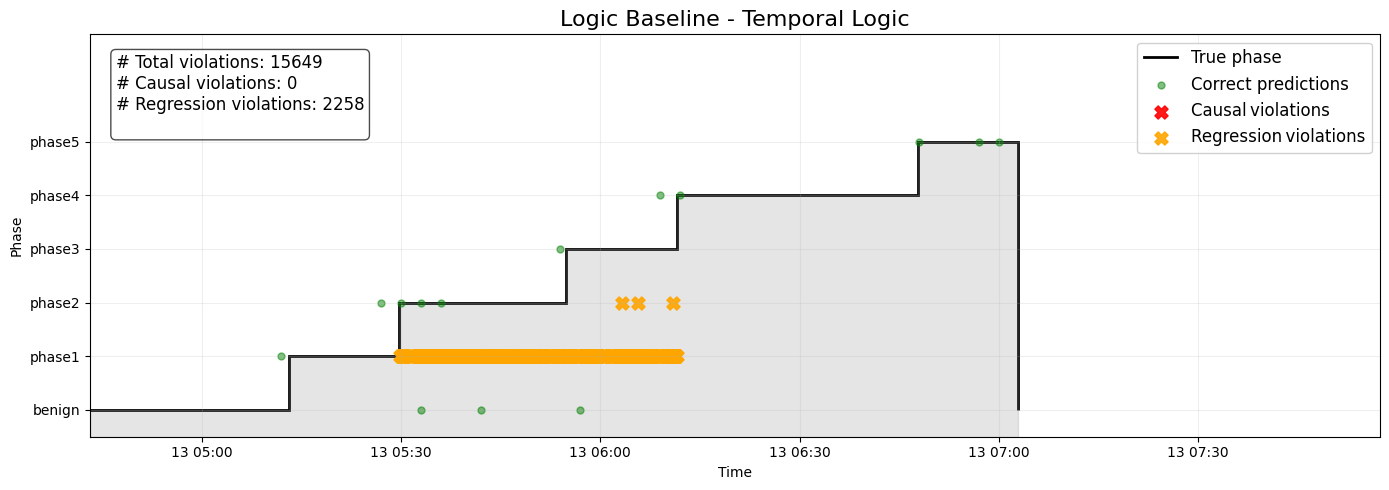

Processing darpa_temp_pretrained_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_pretrained_base_w10_full_0.001lr_full_window.png...


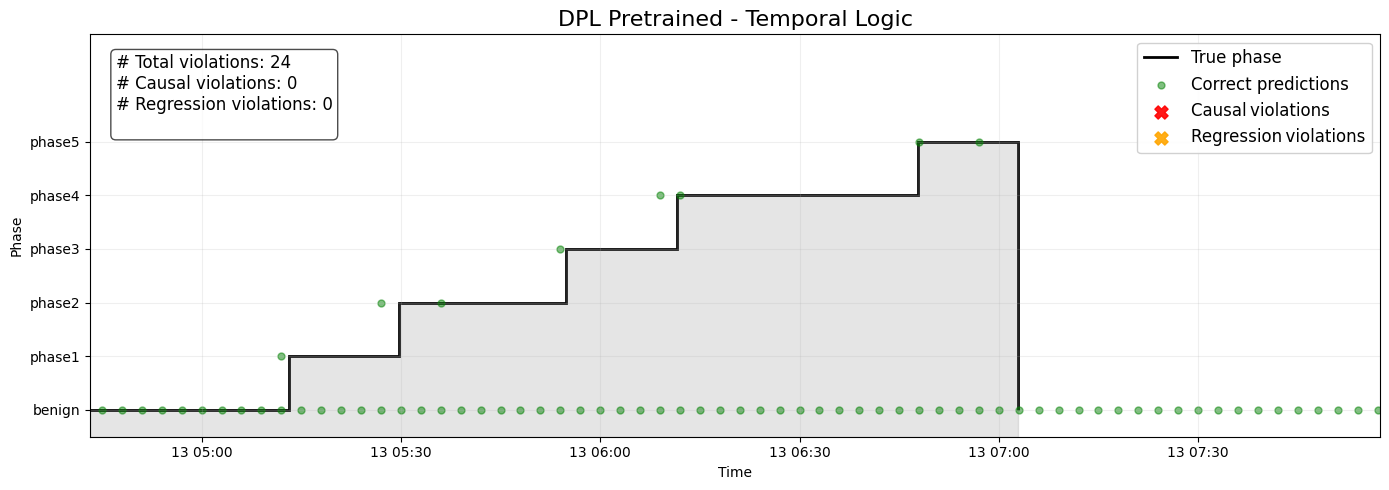

Processing darpa_temp_context_endtoend_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_context_endtoend_base_w10_full_0.001lr_full_window.png...


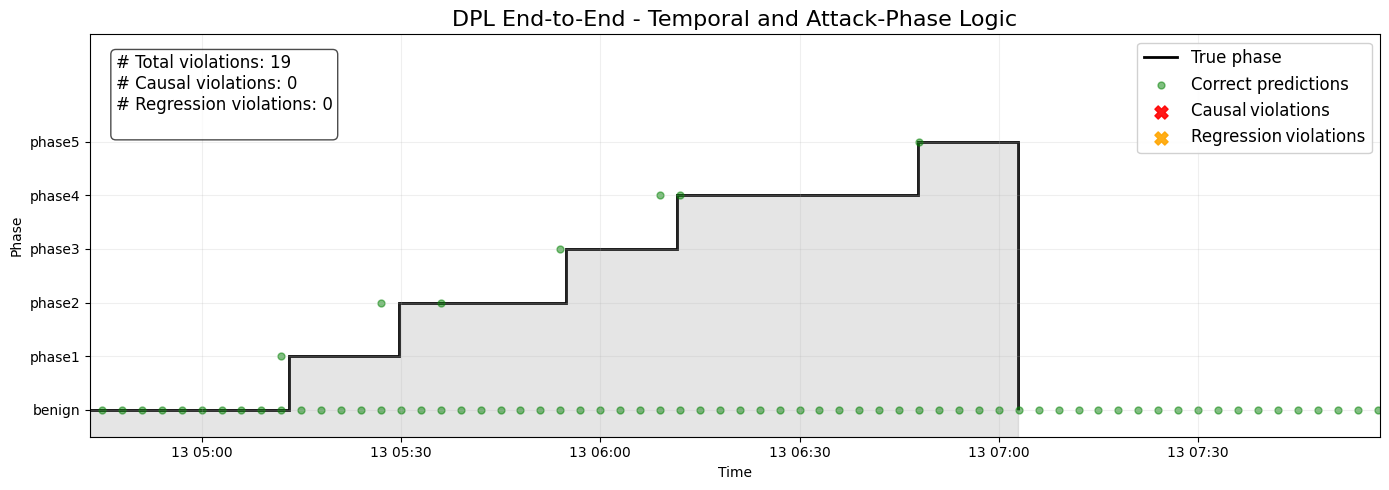

Processing darpa_temp_context_pretrained_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_context_pretrained_base_w10_full_0.001lr_full_window.png...


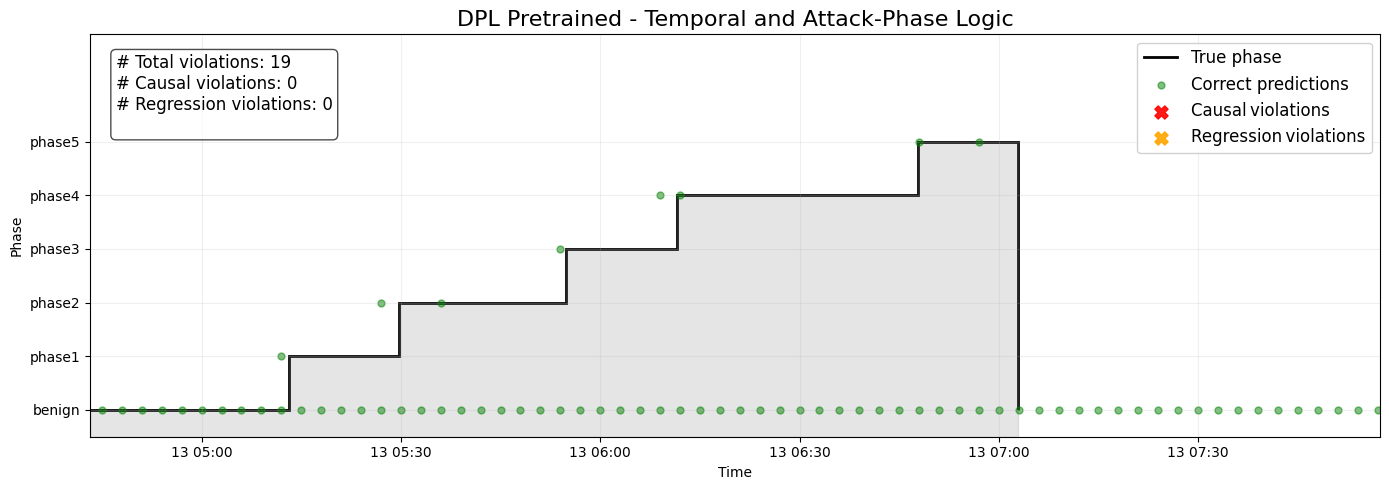

Processing darpa_temp_endtoend_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_endtoend_base_w10_full_0.001lr_full_window.png...


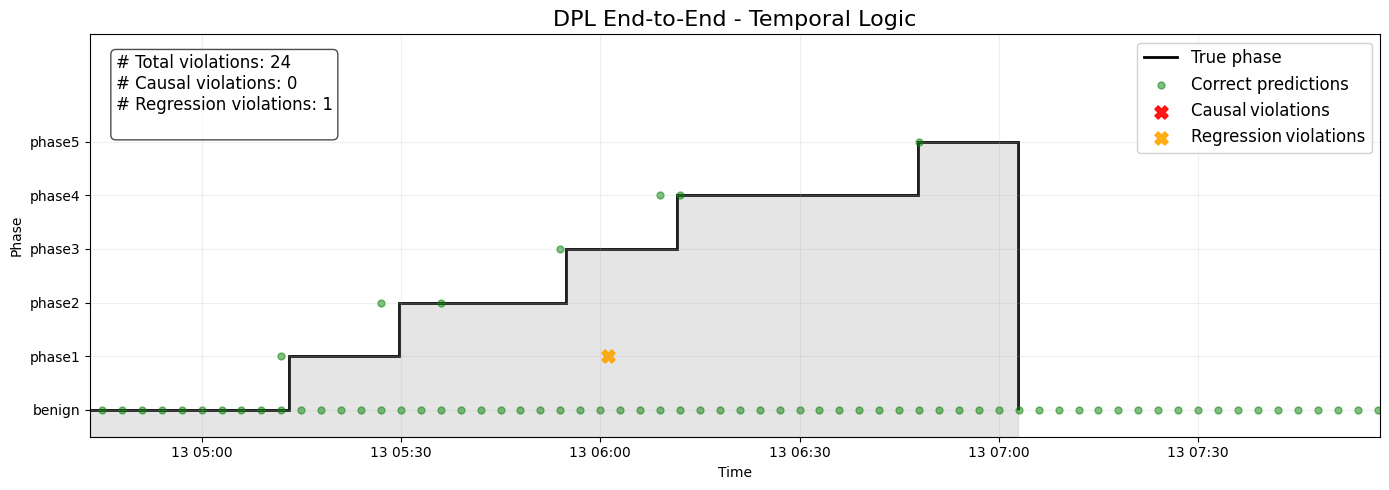

Processing darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr_full_window.png...


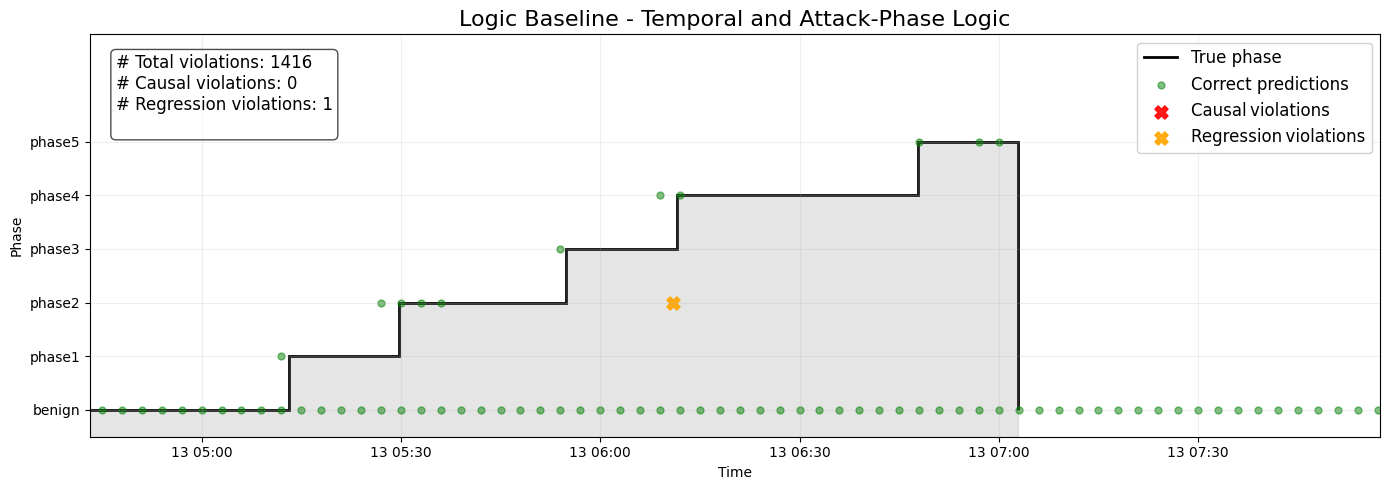

Processing ensemble_basefeatures_w10_fulldata_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/ensemble_basefeatures_w10_fulldata_0.001lr_full_window.png...


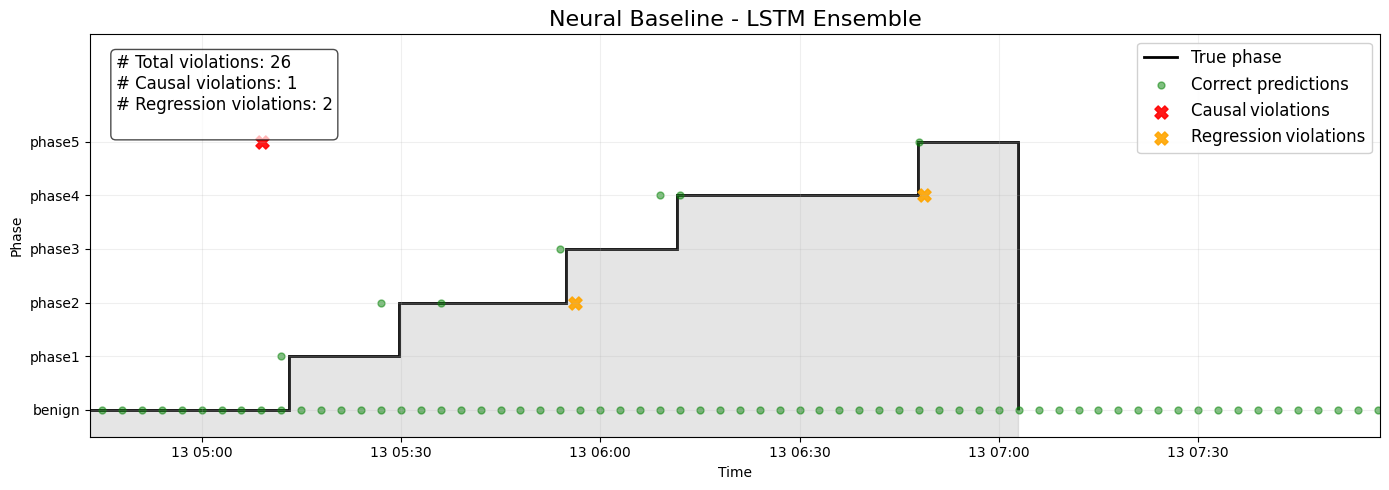

Processing multiclass_basefeatures_w10_fulldata_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/multiclass_basefeatures_w10_fulldata_0.001lr_full_window.png...


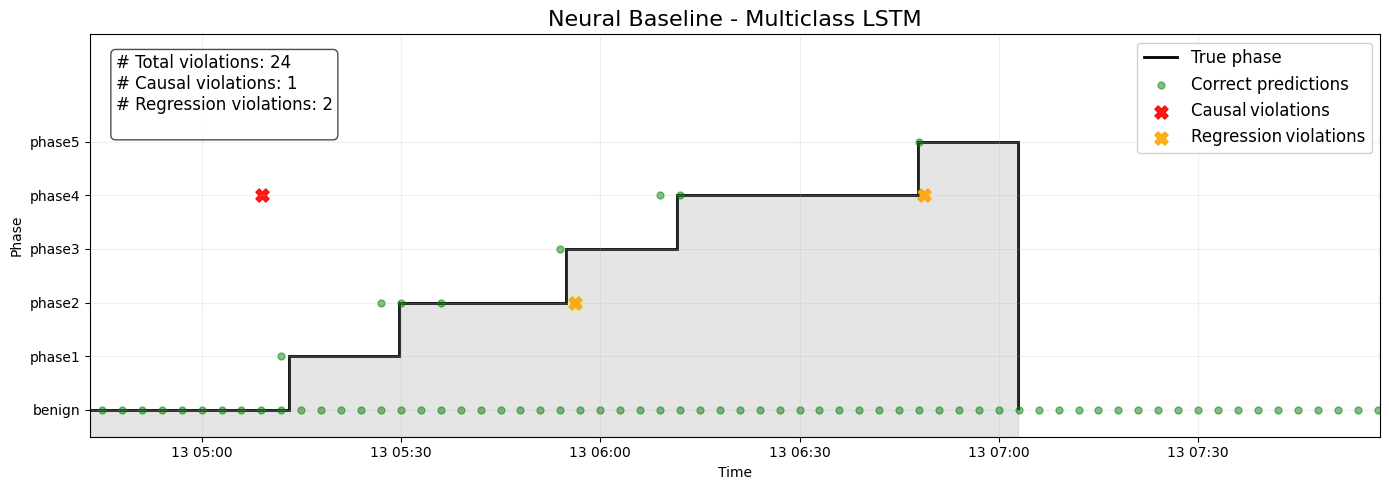

In [ ]:
for experiment_name, metrics in metrics_dict.items():
    print(f"Processing {experiment_name}...")
    
    plot_name = get_plot_name(experiment_name)

    dataframes = dataframes_dict[experiment_name]
    correct_df = dataframes["correct"]
    causal_df = dataframes["causal"]
    regression_df = dataframes["regression"]

    # Plot full window
    correct_attack_df_sampled, correct_benign_df_sampled, correct_df_sampled = \
        sample_correct_predictions(correct_df, time_window="3min")
    
    # start = pd.Timestamp("2022-01-14 12:00")
    # end   = pd.Timestamp("2022-01-17 13:30")
    
    plot_temp_consistency(
        df=df,
        phase_bounds=phase_bounds, 
        correct_df=correct_df_sampled,
        causal_df=causal_df,
        regression_df=regression_df,
        metrics_dict=metrics,
        plot_name=plot_name,
        exp_name=f"{experiment_name}_full_window",
        labels=plot_labels,
        out_dir=plots_dir,
        # attack_start=start,
        # attack_end=end,
        with_metrics_box=True,
        save_plot=True,
        show_plot=True
    )

    if dataset == "aitv2":
        # Zoom in on attack window
        correct_attack_df_sampled, correct_benign_df_sampled, correct_df_sampled = \
            sample_correct_predictions(correct_df, time_window="1min")

        start = attack_start
        end   = pd.Timestamp("2022-01-17 12:05")
        
        plot_temp_consistency(
            df=df,
            phase_bounds=phase_bounds, 
            correct_df=correct_df_sampled,
            causal_df=causal_df,
            regression_df=regression_df,
            metrics_dict=metrics,
            plot_name=plot_name, 
            exp_name=f"{experiment_name}_zoomed_in",
            labels=plot_labels,
            out_dir=plots_dir,
            attack_start=start,
            attack_end=end,
            with_metrics_box=True,
            save_plot=True,
            show_plot=True
        )